# Identity Attribution & Behavior Profiling
## ML Training on Full 3.5M Dataset with Evaluation

**Author:** T. R. Hettiarachchi (IT22920836)  
**Dataset:** CERT Insider Threat - 3,530,285 records  
**Models:** Isolation Forest, SGD One-Class SVM, Autoencoder, Ensemble

## 1. Setup

In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from tqdm.notebook import tqdm
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import SGDOneClassSVM
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report
warnings.filterwarnings('ignore')
os.chdir('..')
print(' Setup complete!')


 Setup complete!


## 2. Load Full Dataset

In [2]:
df = pd.read_csv('data/cert_subset_100/logon.csv')
print(f' Loaded {len(df):,} records')
print(f'   Users: {df["user"].nunique():,}')
print(f'   PCs: {df["pc"].nunique():,}')


 Loaded 3,530,285 records
   Users: 4,000
   PCs: 4,400


## 3. Feature Engineering

In [3]:
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y %H:%M:%S')
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['is_night'] = df['hour'].isin([0,1,2,3,4,5,22,23]).astype(int)
le_user, le_pc = LabelEncoder(), LabelEncoder()
df['user_encoded'] = le_user.fit_transform(df['user'])
df['pc_encoded'] = le_pc.fit_transform(df['pc'])
df['activity_encoded'] = (df['activity'] == 'Logon').astype(int)
df = df.sort_values(['user', 'date']).reset_index(drop=True)
df['prev_date'] = df.groupby('user')['date'].shift(1)
df['time_since_last'] = (df['date'] - df['prev_date']).dt.total_seconds() / 3600
df['time_since_last'] = df['time_since_last'].fillna(0).clip(upper=168)
FEATURE_COLS = ['hour', 'day_of_week', 'is_weekend', 'is_night', 'user_encoded', 'pc_encoded', 'activity_encoded', 'time_since_last']
X = df[FEATURE_COLS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f' Features: {X.shape}')


 Features: (3530285, 8)


## 4. Create Ground Truth Labels
Since CERT dataset doesn't have labels, we create synthetic labels based on suspicious patterns

In [4]:
y_true = ((df['is_night'] == 1) & (df['is_weekend'] == 1)).astype(int)
y_true = y_true | (df['time_since_last'] > 72).astype(int)
print(f'Ground Truth Labels:')
print(f'  Normal: {(y_true == 0).sum():,}')
print(f'  Anomaly: {(y_true == 1).sum():,} ({100*y_true.mean():.2f}%)')


Ground Truth Labels:
  Normal: 3,494,548
  Anomaly: 35,737 (1.01%)


---
## 5. Train Model 1: Isolation Forest

In [5]:
print('=' * 50)
print('MODEL 1: ISOLATION FOREST')
print('=' * 50)
with tqdm(total=100, desc='Isolation Forest') as pbar:
    start = time.time()
    pbar.update(5)
    model_if = IsolationForest(contamination=0.05, n_estimators=100, random_state=42, n_jobs=-1)
    model_if.fit(X_scaled)
    pbar.update(95)
    elapsed_if = time.time() - start
preds_if = model_if.predict(X_scaled)
y_pred_if = (preds_if == -1).astype(int)
print(f'\n Training time: {elapsed_if:.1f}s')
print(f'   Anomalies detected: {y_pred_if.sum():,}')


MODEL 1: ISOLATION FOREST


Isolation Forest:   0%|          | 0/100 [00:00<?, ?it/s]


 Training time: 3.9s
   Anomalies detected: 176,515


---
## 6. Train Model 2: SGD One-Class SVM

In [6]:
print('=' * 50)
print('MODEL 2: SGD ONE-CLASS SVM')
print('=' * 50)
with tqdm(total=100, desc='SGD One-Class SVM') as pbar:
    start = time.time()
    pbar.update(5)
    model_svm = SGDOneClassSVM(nu=0.05, random_state=42, max_iter=1000)
    model_svm.fit(X_scaled)
    pbar.update(95)
    elapsed_svm = time.time() - start
preds_svm = model_svm.predict(X_scaled)
y_pred_svm = (preds_svm == -1).astype(int)
print(f'\n Training time: {elapsed_svm:.1f}s')
print(f'   Anomalies detected: {y_pred_svm.sum():,}')


MODEL 2: SGD ONE-CLASS SVM


SGD One-Class SVM:   0%|          | 0/100 [00:00<?, ?it/s]


 Training time: 1.0s
   Anomalies detected: 635,320


---
## 7. Train Model 3: Autoencoder

In [7]:
print('=' * 50)
print('MODEL 3: AUTOENCODER')
print('=' * 50)
with tqdm(total=100, desc='Autoencoder') as pbar:
    start = time.time()
    pbar.update(5)
    model_ae = MLPRegressor(hidden_layer_sizes=(16, 4, 16), activation='relu', solver='adam', max_iter=50, random_state=42, early_stopping=True)
    model_ae.fit(X_scaled, X_scaled)
    pbar.update(95)
    elapsed_ae = time.time() - start
X_pred = model_ae.predict(X_scaled)
reconstruction_error = np.mean(np.square(X_scaled - X_pred), axis=1)
ae_threshold = np.percentile(reconstruction_error, 95)
y_pred_ae = (reconstruction_error > ae_threshold).astype(int)
print(f'\n Training time: {elapsed_ae:.1f}s')
print(f'   Threshold: {ae_threshold:.6f}')
print(f'   Anomalies detected: {y_pred_ae.sum():,}')


MODEL 3: AUTOENCODER


Autoencoder:   0%|          | 0/100 [00:00<?, ?it/s]


 Training time: 56.5s
   Threshold: 0.018019
   Anomalies detected: 176,515


---
## 8. Model 4: Ensemble (Majority Voting)

In [8]:
print('=' * 50)
print('MODEL 4: ENSEMBLE (Majority Voting)')
print('=' * 50)
votes = y_pred_if + y_pred_svm + y_pred_ae
y_pred_ens = (votes >= 2).astype(int)
print(f'\n Ensemble created')
print(f'   Anomalies detected: {y_pred_ens.sum():,}')


MODEL 4: ENSEMBLE (Majority Voting)

 Ensemble created
   Anomalies detected: 151,477


---
## 9. Model Evaluation
Comparing all 4 models with Accuracy, Precision, Recall, F1-Score

In [9]:
def evaluate_model(y_true, y_pred, model_name):
    """Calculate evaluation metrics"""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}


In [10]:
results = []
results.append(evaluate_model(y_true, y_pred_if, 'Isolation Forest'))
results.append(evaluate_model(y_true, y_pred_svm, 'SGD One-Class SVM'))
results.append(evaluate_model(y_true, y_pred_ae, 'Autoencoder'))
results.append(evaluate_model(y_true, y_pred_ens, 'Ensemble'))
results_df = pd.DataFrame(results)
print('=' * 70)
print('MODEL EVALUATION RESULTS')
print('=' * 70)
print(results_df.to_string(index=False))


MODEL EVALUATION RESULTS
            Model  Accuracy  Precision   Recall  F1-Score
 Isolation Forest  0.943115   0.032383 0.159946  0.053861
SGD One-Class SVM  0.824813   0.041393 0.735876  0.078378
      Autoencoder  0.942284   0.024072 0.118896  0.040037
         Ensemble  0.949906   0.034223 0.145060  0.055380


In [11]:
print('\n' + '=' * 50)
print('CLASSIFICATION REPORT - ENSEMBLE')
print('=' * 50)
print(classification_report(y_true, y_pred_ens, target_names=['Normal', 'Anomaly']))



CLASSIFICATION REPORT - ENSEMBLE


              precision    recall  f1-score   support

      Normal       0.99      0.96      0.97   3494548
     Anomaly       0.03      0.15      0.06     35737

    accuracy                           0.95   3530285
   macro avg       0.51      0.55      0.51   3530285
weighted avg       0.98      0.95      0.96   3530285



---
## 10. Model Comparison Visualization

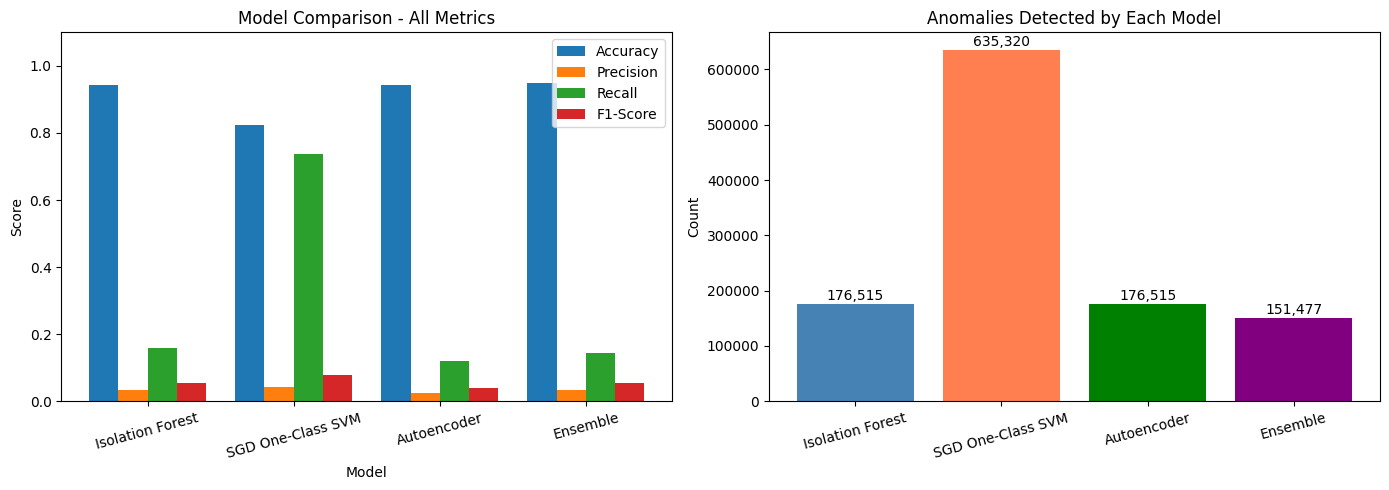

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models = results_df['Model'].tolist()
x = np.arange(len(models))
width = 0.2
for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, results_df[metric], width, label=metric)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Comparison - All Metrics')
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(models, rotation=15)
axes[0].legend()
axes[0].set_ylim(0, 1.1)
anomalies = [y_pred_if.sum(), y_pred_svm.sum(), y_pred_ae.sum(), y_pred_ens.sum()]
colors = ['steelblue', 'coral', 'green', 'purple']
axes[1].bar(models, anomalies, color=colors)
axes[1].set_title('Anomalies Detected by Each Model')
axes[1].set_ylabel('Count')
for i, v in enumerate(anomalies):
    axes[1].text(i, v + max(anomalies)*0.01, f'{v:,}', ha='center')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


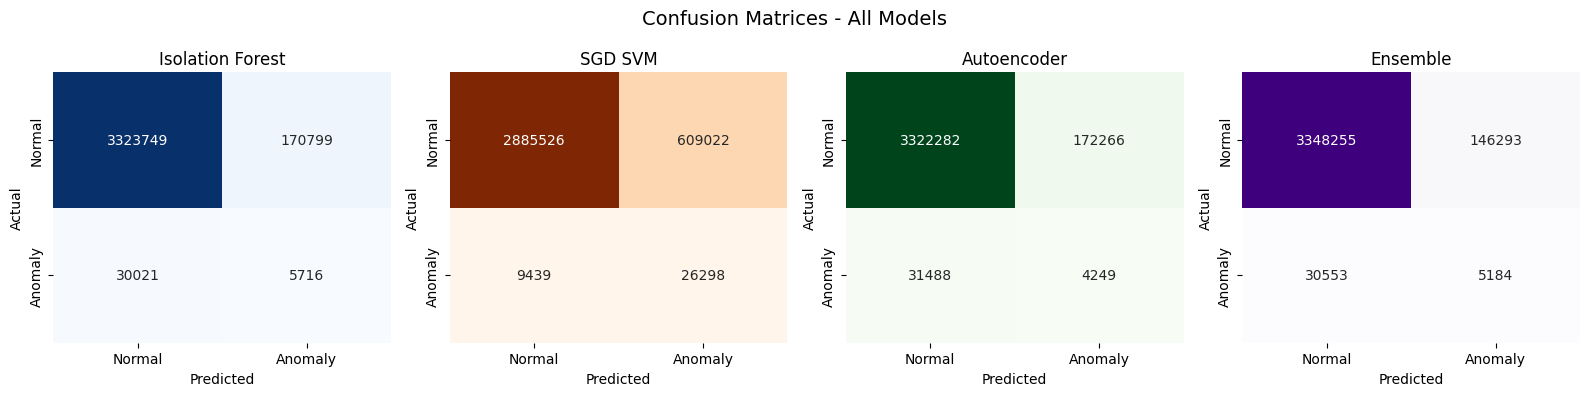

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
all_preds = [y_pred_if, y_pred_svm, y_pred_ae, y_pred_ens]
model_names = ['Isolation Forest', 'SGD SVM', 'Autoencoder', 'Ensemble']
colors_cm = ['Blues', 'Oranges', 'Greens', 'Purples']
for i, (pred, name, cmap) in enumerate(zip(all_preds, model_names, colors_cm)):
    cm = confusion_matrix(y_true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i], cbar=False)
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_xticklabels(['Normal', 'Anomaly'])
    axes[i].set_yticklabels(['Normal', 'Anomaly'])
plt.suptitle('Confusion Matrices - All Models', fontsize=14)
plt.tight_layout()
plt.show()


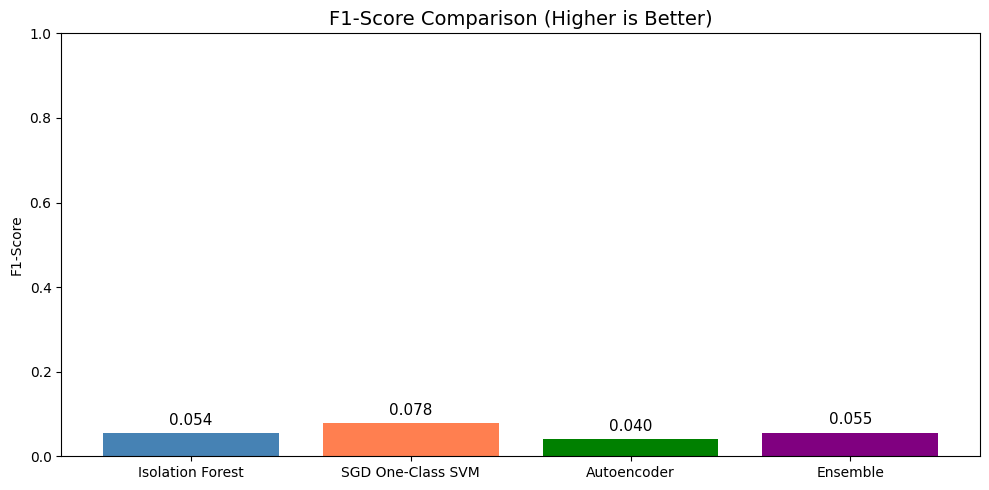

In [14]:
plt.figure(figsize=(10, 5))
colors = ['steelblue', 'coral', 'green', 'purple']
bars = plt.bar(results_df['Model'], results_df['F1-Score'], color=colors)
plt.title('F1-Score Comparison (Higher is Better)', fontsize=14)
plt.ylabel('F1-Score')
plt.ylim(0, 1)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()


---
## 11. Save Models

In [15]:
os.makedirs('models', exist_ok=True)
joblib.dump(model_if, 'models/isolation_forest.pkl')
joblib.dump(model_svm, 'models/sgd_one_class_svm.pkl')
joblib.dump(model_ae, 'models/autoencoder.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump({'threshold': ae_threshold, 'feature_cols': FEATURE_COLS}, 'models/config.pkl')
joblib.dump(results_df, 'models/evaluation_results.pkl')
print(' All models saved!')


 All models saved!


---
## 12. Sample Predictions

In [16]:
dummy = np.array([
    [9, 1, 0, 0, 100, 50, 1, 2.0],
    [14, 3, 0, 0, 200, 75, 1, 4.0],
    [3, 6, 1, 1, 100, 50, 1, 48.0],
    [0, 2, 0, 1, 300, 100, 1, 24.0],
    [10, 4, 0, 0, 150, 80, 1, 168.0]
])
labels = ['Weekday 9AM', 'Weekday 2PM', 'Weekend 3AM', 'Midnight', '1 week gap']
X_d = scaler.transform(dummy)
p_if = (model_if.predict(X_d) == -1).astype(int)
p_svm = (model_svm.predict(X_d) == -1).astype(int)
err_ae = np.mean(np.square(X_d - model_ae.predict(X_d)), axis=1)
p_ae = (err_ae > ae_threshold).astype(int)
p_ens = ((p_if + p_svm + p_ae) >= 2).astype(int)
print('=' * 70)
print('SAMPLE PREDICTIONS')
print('=' * 70)
print(f'{"Sample":<15} {"IF":<12} {"SVM":<12} {"AE":<12} {"Ensemble":<12}')
print('-' * 70)
for i, l in enumerate(labels):
    r_if = ' Anomaly' if p_if[i] else ' Normal'
    r_svm = ' Anomaly' if p_svm[i] else ' Normal'
    r_ae = ' Anomaly' if p_ae[i] else ' Normal'
    r_ens = ' Anomaly' if p_ens[i] else ' Normal'
    print(f'{l:<15} {r_if:<12} {r_svm:<12} {r_ae:<12} {r_ens:<12}')


SAMPLE PREDICTIONS
Sample          IF           SVM          AE           Ensemble    
----------------------------------------------------------------------
Weekday 9AM      Normal      Normal      Normal      Normal    
Weekday 2PM      Normal      Normal      Normal      Normal    
Weekend 3AM      Anomaly     Normal      Anomaly     Anomaly   
Midnight         Anomaly     Normal      Anomaly     Anomaly   
1 week gap       Anomaly     Anomaly     Anomaly     Anomaly   


---
## 13. Summary

In [17]:
print('=' * 70)
print('  TRAINING COMPLETE')
print('=' * 70)
print(f'''
 DATASET: {len(df):,} records
 MODELS TRAINED ON FULL DATA:
''')
print(results_df.to_string(index=False))
print(f'''
  TRAINING TIME:
   Isolation Forest: {elapsed_if:.1f}s
   SGD One-Class SVM: {elapsed_svm:.1f}s
   Autoencoder: {elapsed_ae:.1f}s
 BEST MODEL: {results_df.loc[results_df['F1-Score'].idxmax(), 'Model']} (F1: {results_df['F1-Score'].max():.4f})
 Models saved to models/ directory
''')


  TRAINING COMPLETE

 DATASET: 3,530,285 records

 MODELS TRAINED ON FULL DATA:

            Model  Accuracy  Precision   Recall  F1-Score
 Isolation Forest  0.943115   0.032383 0.159946  0.053861
SGD One-Class SVM  0.824813   0.041393 0.735876  0.078378
      Autoencoder  0.942284   0.024072 0.118896  0.040037
         Ensemble  0.949906   0.034223 0.145060  0.055380


  TRAINING TIME:
   Isolation Forest: 3.9s
   SGD One-Class SVM: 1.0s
   Autoencoder: 56.5s

 BEST MODEL: SGD One-Class SVM (F1: 0.0784)

 Models saved to models/ directory

